# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

1. SAX — превращает временной ряд в последовательность букв, усредняя значения на отрезках. SFA — раскладывает сигнал на синусы и косинусы, а потом превращает коэффициенты в буквы. SFA лучше, потому что шум — это высокие частоты, а SFA их отсекает, оставляя только основную мелодию сигнала.
2. BOSS разбивает ряд на кусочки, превращает каждый в буквы (через SFA) и считает, какие буквы как часто встречаются. TF-IDF — это идея из поиска документов: редкое слово важнее частого. В BOSS редкие паттерны (символы) получают больший вес — они лучше отличают один класс от другого. Смысл: найти уникальные "слова" (паттерны), которые встречаются только у одного типа сигналов.
3. Shapelet — это самый полезный кусочек временного ряда, который лучше всего отделяет один класс от другого (например, острый пик или плато). ROCKET не ищет лучшие кусочки, а берет тысячи случайных и проверяет, какие сработали.
4. Нейросеть учится сама искать признаки, но нужно много данных, может выучить шум вместо сигнала, непонятно, на что она смотрит (черный ящик).
5. 1D-CNN работает как лупа, которая скользит по сигналу и ищет локальные узоры (пик, провал, плато).
Многоветвевость (Inception Time) — это несколько луп разного размера одновременно:
Короткая лупа (длина 3) — ловит быстрые импульсы
Средняя лупа (длина 10) — ловит более длинные паттерны
Длинная лупа (длина 30) — ловит медленные тренды

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


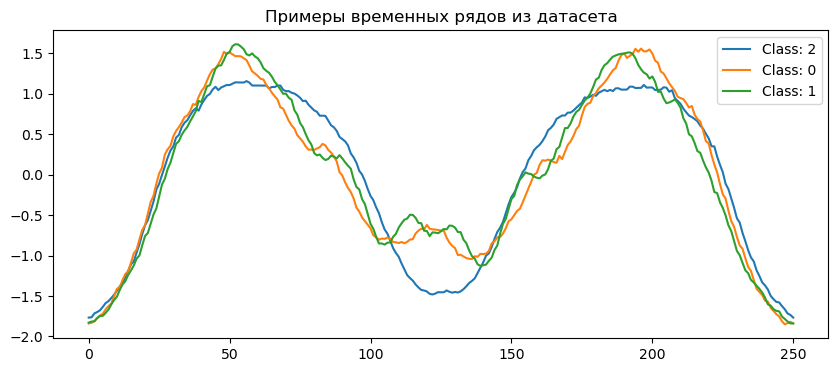

In [2]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [3]:
from sktime.classification.kernel_based import RocketClassifier
import time

# Ваш код здесь...

# Инициализация классификатора
rocket = RocketClassifier(
    num_kernels=10000,      # количество случайных ядер
    random_state=42
)

# Замер времени обучения
start_time = time.time()
rocket.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"Время обучения: {train_time:.4f} секунд")

# 2. Предсказание и оценка качества
start_time = time.time()
y_pred = rocket.predict(X_test)
predict_time = time.time() - start_time

print(f"Время предсказания: {predict_time:.4f} секунд")

# Точность
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy ROCKET: {accuracy:.4f}")

# Детальный отчет
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Время обучения: 44.3353 секунд
Время предсказания: 9.0773 секунд

Accuracy ROCKET: 0.9375

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        28
           1       0.94      0.94      0.94        17
           2       0.94      0.89      0.92        19

    accuracy                           0.94        64
   macro avg       0.94      0.93      0.94        64
weighted avg       0.94      0.94      0.94        64



### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [4]:
from sktime.classification.dictionary_based import ContractableBOSS

# Ваш код здесь...

import time

# Инициализация ContractableBOSS
boss = ContractableBOSS(random_state=42, time_limit_in_minutes=1)

# Замер времени обучения
start_time = time.time()
boss.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"Время обучения: {train_time:.4f} сек")

# Предсказание
start_time = time.time()
y_pred_boss = boss.predict(X_test)
predict_time = time.time() - start_time

print(f"Время предсказания: {predict_time:.4f} сек")

# Точность
accuracy_boss = accuracy_score(y_test, y_pred_boss)
print(f"Accuracy: {accuracy_boss:.4f}")
print(classification_report(y_test, y_pred_boss))

Время обучения: 55.7238 сек
Время предсказания: 7.7316 сек
Accuracy: 0.9531
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.89      0.94      0.91        17
           2       0.94      0.89      0.92        19

    accuracy                           0.95        64
   macro avg       0.94      0.95      0.94        64
weighted avg       0.95      0.95      0.95        64



### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

# Не понимаю как решить проблему с библиотекой torch, перепробовала еще варианты, ничего не работает

OSError: [WinError 1114] Произошел сбой в программе инициализации библиотеки динамической компоновки (DLL). Error loading "c:\Users\MyComp\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [ ]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x


[TensorFlow DLL Diagnostic] Analyzing: c:\Users\MyComp\anaconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.


ImportError: Traceback (most recent call last):
  File "c:\Users\MyComp\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 74, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: Произошел сбой в программе инициализации библиотеки динамической компоновки (DLL).


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [13]:
# ваш код здесь